# Autoencoders — TensorFlow / Keras (CPU)

## Model: Dense Autoencoder + Convolutional Denoising Autoencoder
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 3,072 features (32×32×3 RGB)
- **Task**: Reconstruct input images through bottleneck compression (self-supervised)
- **Framework showcase**: Keras Functional API conv denoising AE — architecture sweep + noise type comparison (Gaussian vs salt-and-pepper)

## CPU Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Keras Sequential API for dense AE baseline
- Keras Functional API for conv AE — enables separate encoder/decoder models
- Built-in `model.fit()` with validation_split, EarlyStopping callback

## Evaluation Strategy
- **Metrics**: Reconstruction MSE/MAE, downstream KNN accuracy (K=5) on latent features
- **Visualizations**: Reconstruction grids (RGB), training loss curves, latent space t-SNE

## Pipeline
1. Load data + config
2. Simple dense autoencoder (baseline, match SK/PT)
3. Training history + reconstruction visualization
4. Conv denoising AE — architecture sweep + noise type comparison (showcase)
5. Dense vs best conv denoising comparison
6. Latent space + downstream classification
7. Performance benchmarks
8. Save results

In [1]:
# Step 1: Setup

"""
Imports, config, load preprocessed CIFAR-10
TF runs on CPU (no Windows GPU support for TF 2.11+)
Keras Functional API enables separate encoder/decoder models
"""

import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tensorflow as tf
from tensorflow import keras

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_training_history, plot_reconstruction_grid,
                                  plot_latent_space)
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "Autoencoder"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

IMAGE_SHAPE = (32, 32, 3)
N_FEATURES = 3072  # 32 * 32 * 3
N_CHANNELS = 3
BATCH_SIZE = 128
LATENT_DIM = 128  # Baseline bottleneck (matches SK/PT)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Load preprocessed CIFAR-10 — flattened for dense AE
X_train_flat, X_test_flat, y_train, y_test, metadata = load_processed_data('autoencoder')

# Image-shaped data for conv AE — channel-last (TF native format)
X_train_img = np.load('../../data/processed/autoencoder/X_train_img.npy')
X_test_img = np.load('../../data/processed/autoencoder/X_test_img.npy')

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} {MODEL_NAME}")
print("=" * 60)
print(f"  Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"  TF version: {tf.__version__}")
print(f"  Train flat: {X_train_flat.shape} | Test flat: {X_test_flat.shape}")
print(f"  Train img:  {X_train_img.shape} | Test img:  {X_test_img.shape}")
print(f"  Classes: {len(CLASS_NAMES)}")
print(f"  Pixel range: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]")
print(f"  Dtype: {X_train_flat.dtype}")

[1/8] Data loaded — TensorFlow Autoencoder
  Device: CPU (TF 2.11+ dropped native Windows GPU)
  TF version: 2.20.0
  Train flat: (50000, 3072) | Test flat: (10000, 3072)
  Train img:  (50000, 32, 32, 3) | Test img:  (10000, 32, 32, 3)
  Classes: 10
  Pixel range: [0.0, 1.0]
  Dtype: float32


In [2]:
# Step 2: Simple Dense Autoencoder 

"""
Keras Sequential: 3072 → 512 → 128 → 512 → 3072
Sigmoid output maps to [0,1] pixel space
model.fit() with validation_split and EarlyStopping callback
"""

print("=" * 60)
print("[2/8] Simple Dense Autoencoder — Baseline")
print("=" * 60)

# Build dense autoencoder — Keras Sequential
dense_ae = keras.Sequential([
    keras.layers.Input(shape=(N_FEATURES,)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(LATENT_DIM, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(N_FEATURES, activation='sigmoid')
])

dense_ae.compile(optimizer='adam', loss='mse')
dense_ae.summary()

# EarlyStopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Train — input IS the target
with track_performance() as perf:
    history = dense_ae.fit(
        X_train_flat, X_train_flat,
        epochs=200,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

# Reconstruct test set
X_test_recon = dense_ae.predict(X_test_flat, verbose=0)

# Reconstruction metrics
baseline_mse = float(np.mean((X_test_flat - X_test_recon) ** 2))
baseline_mae = float(np.mean(np.abs(X_test_flat - X_test_recon)))

n_params = dense_ae.count_params()
best_epoch = len(history.history['loss']) - 15  # approximate

print(f"\nArchitecture: 3072 → 512 → 128 → 512 → 3072")
print(f"Epochs: {len(history.history['loss'])} (early stopped ~epoch {best_epoch})")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Training time: {perf['time']:.2f}s")
print(f"Peak memory: {perf['memory']:.2f} MB")
print(f"\nReconstruction Quality (test set):")
print(f"  MSE:  {baseline_mse:.6f}")
print(f"  MAE:  {baseline_mae:.6f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.6f}")
print(f"\nParameters: {n_params:,}")
print(f"\nSK baseline: MSE 0.0133 | PT baseline: MSE 0.0091")

[2/8] Simple Dense Autoencoder — Baseline


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3072)           │     1,575,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,281,024 (12.52 MB)

 Trainable params: 3,281,024 (12.52 MB)

 Non-trainable params: 0 (0.00 B)


Architecture: 3072 → 512 → 128 → 512 → 3072
Epochs: 123 (early stopped ~epoch 108)
Best val loss: 0.009346
Training time: 340.01s
Peak memory: 1200.55 MB

Reconstruction Quality (test set):
  MSE:  0.009407
  MAE:  0.070213
  RMSE: 0.096991

Parameters: 3,281,024

SK baseline: MSE 0.0133 | PT baseline: MSE 0.0091


[3/8] Visualizations


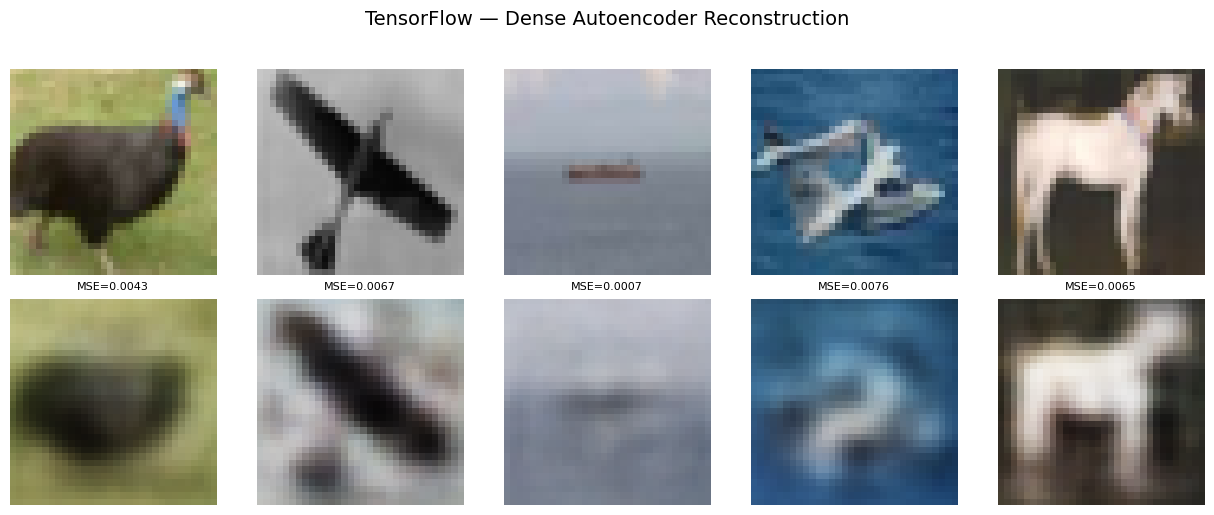

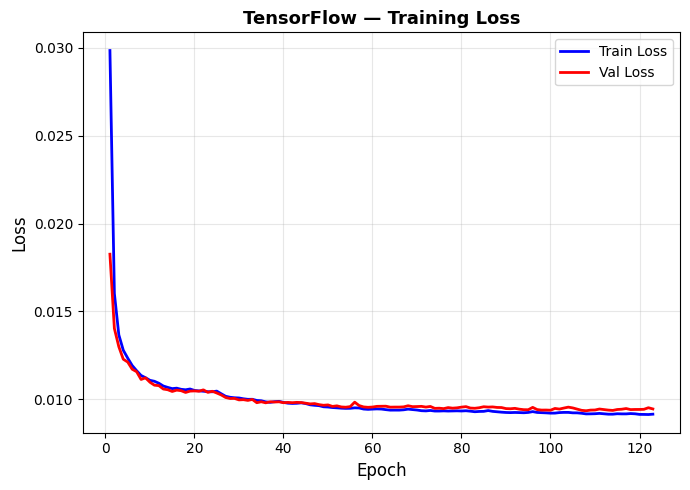


Training: 123 epochs
Final train loss: 0.009149
Best val loss:    0.009346


In [3]:
# Step 3: Visualizations

# Reconstruction grid (RGB) + training loss curve


print("=" * 60)
print("[3/8] Visualizations")
print("=" * 60)

# Reconstruction Grid
rng_viz = np.random.RandomState(RANDOM_STATE)
viz_idx = rng_viz.choice(len(X_test_flat), 5, replace=False)

recon_dict = {128: X_test_recon[viz_idx]}
plot_reconstruction_grid(
    originals=X_test_flat[viz_idx],
    reconstructions_dict=recon_dict,
    image_shape=IMAGE_SHAPE,
    n_samples=5,
    title='Dense Autoencoder Reconstruction',
    row_label_prefix='dim',
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/reconstruction_dense.png'
)

# Training Loss Curve
train_history = {
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

plot_training_history(
    history=train_history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_dense.png'
)

print(f"\nTraining: {len(history.history['loss'])} epochs")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Best val loss:    {min(history.history['val_loss']):.6f}")